In [57]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os

In [58]:
'''data = pd.read_csv("online_gaming_behavior_dataset.csv") //testing purpose
data'''

'data = pd.read_csv("online_gaming_behavior_dataset.csv") //testing purpose\ndata'

In [59]:
# Download dataset
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
data = pd.read_csv(os.path.join(path, csv_file))
data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [60]:
data.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [61]:
 data.isna().sum() #any missing value, show 0

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [62]:
data.duplicated().sum()  #any duplicated value, show 0

np.int64(0)

In [63]:
data["Gender_01"] = data["Gender"].map({"Male":0, "Female":1})
data["GameDifficulty_012"] = data["GameDifficulty"].map({"Easy":0, "Medium":1, "Hard":2})
data["EngagementLevel_012"] = data["EngagementLevel"].map({"Easy":0, "Medium":1, "High":2})
data["Location1_123"] = data["Location"].astype("category").cat.codes
data["GameGenre_123"] = data["GameGenre"].astype("category").cat.codes

data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Gender_01,GameDifficulty_012,EngagementLevel_012,Location1_123,GameGenre_123
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,0,1,1.0,2,4
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,1,1,1.0,3,4
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,1,0,2.0,3,3
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,0,0,1.0,3,0
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,0,1,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium,0,0,1.0,3,4
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High,1,2,2.0,2,2
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High,1,0,2.0,3,1
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium,0,1,1.0,3,3


In [64]:
data_selected = data.loc[:, ['Age','PlayTimeHours','SessionsPerWeek','AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked']]  #used to check outlier
data_selected

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
0,43,16.271119,6,108,79,25
1,29,5.525961,5,144,11,10
2,22,8.223755,16,142,35,41
3,35,5.265351,9,85,57,47
4,33,15.531945,2,131,95,37
...,...,...,...,...,...,...
40029,32,20.619662,4,75,85,14
40030,44,13.539280,19,114,71,27
40031,15,0.240057,10,176,29,1
40032,34,14.017818,3,128,70,10


In [65]:
import numpy as np
import pandas as pd

def outliers_iqr_df(data_selected):
    
    outliers_dict = {}
    
    for col in data_selected.columns:
        series = data_selected[col] 
        
        q1, q3 = np.percentile(series, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # find outliers
        mask = (series < lower_bound) | (series > upper_bound)
        outliers = series[mask]
        
        # output result
        if outliers.empty:
            print(f"{col} outlier: 0")
            outliers_dict[col] = 0
        else:
            print(f"{col} outlier:")
            print(outliers.values)
            print(outliers.index)
            outliers_dict[col] = outliers
        
        print("-" * 30)

In [66]:
outliers_iqr_df(data_selected)  #outlierdetection, How to use:outliers_iqr_df(?) ?=dataframe

Age outlier: 0
------------------------------
PlayTimeHours outlier: 0
------------------------------
SessionsPerWeek outlier: 0
------------------------------
AvgSessionDurationMinutes outlier: 0
------------------------------
PlayerLevel outlier: 0
------------------------------
AchievementsUnlocked outlier: 0
------------------------------


In [67]:
data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Gender_01,GameDifficulty_012,EngagementLevel_012,Location1_123,GameGenre_123
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,0,1,1.0,2,4
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,1,1,1.0,3,4
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,1,0,2.0,3,3
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,0,0,1.0,3,0
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,0,1,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium,0,0,1.0,3,4
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High,1,2,2.0,2,2
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High,1,0,2.0,3,1
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium,0,1,1.0,3,3


DATA SELECT AND FIND CORRELATION, 2 METHODS FOR BOTH Nominal AND Ordinal Variable

In [68]:
data_selected = data.loc[:, ['Location','GameGenre','InGamePurchases','GameDifficulty','EngagementLevel']]  #used to check outlier
data_selected

,Location,GameGenre,InGamePurchases,GameDifficulty,EngagementLevel
0,Other,Strategy,0,Medium,Medium
1,USA,Strategy,0,Medium,Medium
2,USA,Sports,0,Easy,High
3,USA,Action,1,Easy,Medium
4,Europe,Action,0,Medium,Medium
...,...,...,...,...,...
40029,USA,Strategy,0,Easy,Medium
40030,Other,Simulation,0,Hard,High
40031,USA,RPG,1,Easy,High
40032,USA,Sports,1,Medium,Medium


In [69]:
#Correlation between type data and participation, Ordinal Logistic Regression
!pip install pandas numpy statsmodels 
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel

# 自变量
X = pd.get_dummies(data_selected[['Location','GameGenre','InGamePurchases','GameDifficulty']], drop_first=True)
X = X.astype(float)

# 目标变量
y = pd.Categorical(data_selected['EngagementLevel'], categories=['Low','Medium','High'], ordered=True)
y_num = y.codes

# 建立模型
model = OrderedModel(y_num, X, distr='logit')
result = model.fit(method='bfgs')
print(result.summary())

# 预测概率
pred = result.predict(X)
print(pred.head())

Optimization terminated successfully.
         Current function value: 1.050193
         Iterations: 37
         Function evaluations: 39
         Gradient evaluations: 39
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -42043.
Model:                   OrderedModel   AIC:                         8.411e+04
Method:            Maximum Likelihood   BIC:                         8.421e+04
Date:                Sun, 05 Apr 2026                                         
Time:                        15:55:45                                         
No. Observations:               40034                                         
Df Residuals:                   40022                                         
Df Model:                          10                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

In [70]:
import pandas as pd   #Correlation between type data and participation, Cramér's V
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

cols = [
    'EngagementLevel',
    'Location',
    'GameGenre',
    'GameDifficulty',
    'InGamePurchases'
]

cramers_matrix = pd.DataFrame(
    np.zeros((len(cols), len(cols))),
    index=cols,
    columns=cols
)

for col1 in cols:
    for col2 in cols:
        cramers_matrix.loc[col1, col2] = cramers_v(data_selected[col1], data_selected[col2])

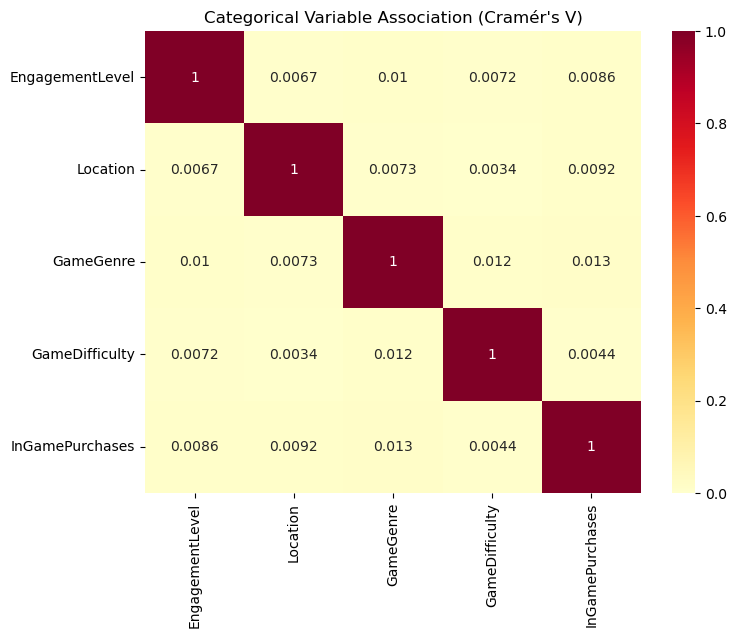

In [71]:
import seaborn as sns  #heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="YlOrRd",
    vmin=0, 
    vmax=1
)

plt.title("Categorical Variable Association (Cramér's V)")
plt.show()

DATA SELECT AND GENERATE HEATMAP (HERE ARE 2 METHODS FOR BOTH ORDINAL AND CONTINUOUS VARIABLE)

In [72]:
data_selected = data.loc[:, ['Age','PlayTimeHours','SessionsPerWeek','AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked','EngagementLevel']] 
data_selected

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,16.271119,6,108,79,25,Medium
1,29,5.525961,5,144,11,10,Medium
2,22,8.223755,16,142,35,41,High
3,35,5.265351,9,85,57,47,Medium
4,33,15.531945,2,131,95,37,Medium
...,...,...,...,...,...,...,...
40029,32,20.619662,4,75,85,14,Medium
40030,44,13.539280,19,114,71,27,High
40031,15,0.240057,10,176,29,1,High
40032,34,14.017818,3,128,70,10,Medium


Spearman #better for the case

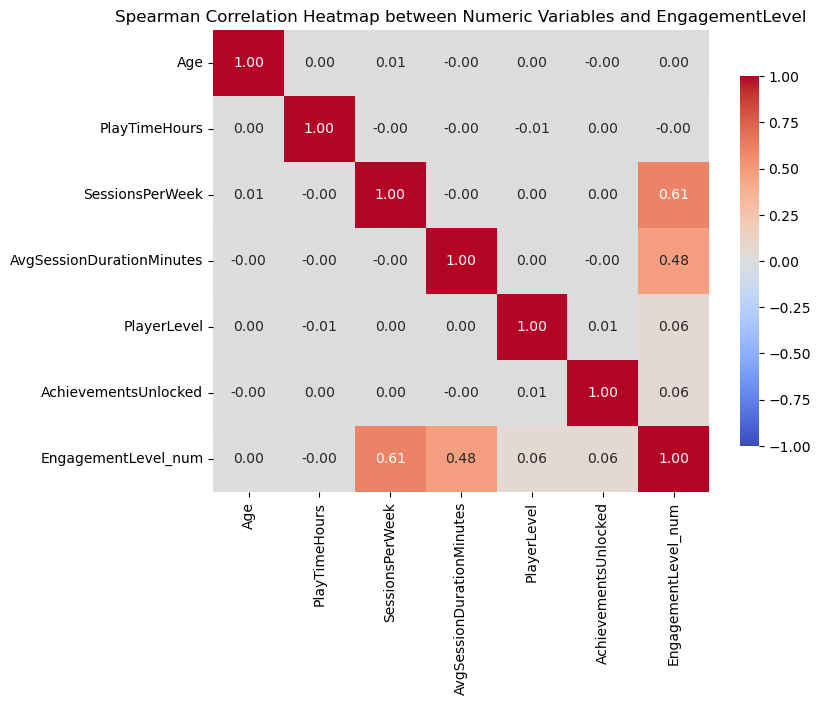

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# turn to 0 1 2
data_selected["EngagementLevel_num"] = pd.Categorical(
    data_selected["EngagementLevel"],
    categories=["Low", "Medium", "High"], 
    ordered=True
).codes

num_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel_num']

# calculate Spearman Correlation coefficient matrix
corr_matrix = data_selected[num_cols].corr(method='spearman')

# draw heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": .8}
)
plt.title("Spearman Correlation Heatmap between Numeric Variables and EngagementLevel")
plt.show()

Pearson

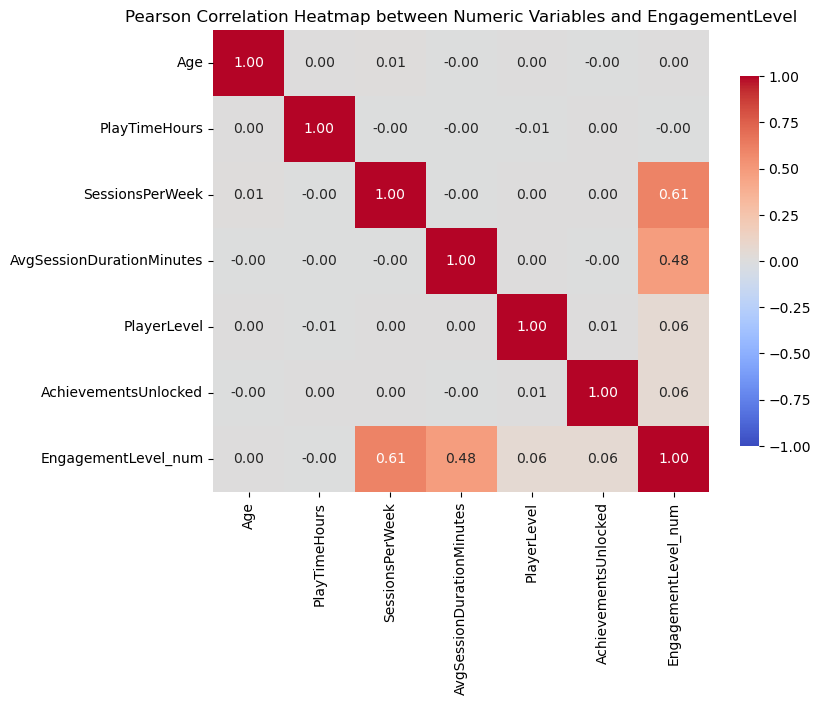

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# turn to 0 1 2
data_selected["EngagementLevel_num"] = pd.Categorical(
    data_selected["EngagementLevel"],
    categories=["Low", "Medium", "High"],
    ordered=True
).codes

num_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel_num']

# calculate Pearson Correlation coefficient matrix
corr_matrix_pearson = data_selected[num_cols].corr(method='pearson')

# draw heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": .8}
)
plt.title("Pearson Correlation Heatmap between Numeric Variables and EngagementLevel")
plt.show()

DATA SELECT (DROPPED CONTRIBUTLESS DATA) AND SPLIT

In [75]:
data_selected = data.loc[:, ['Age','PlayTimeHours','SessionsPerWeek','AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked','EngagementLevel']] 
data_selected

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,16.271119,6,108,79,25,Medium
1,29,5.525961,5,144,11,10,Medium
2,22,8.223755,16,142,35,41,High
3,35,5.265351,9,85,57,47,Medium
4,33,15.531945,2,131,95,37,Medium
...,...,...,...,...,...,...,...
40029,32,20.619662,4,75,85,14,Medium
40030,44,13.539280,19,114,71,27,High
40031,15,0.240057,10,176,29,1,High
40032,34,14.017818,3,128,70,10,Medium


In [76]:
from sklearn.model_selection import train_test_split

X = data[['SessionsPerWeek','AvgSessionDurationMinutes']]
y = data['EngagementLevel_012']

from sklearn.model_selection import train_test_split

# Train 70%, Test 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 28023, Test size: 12011


DATA SCALLING

In [77]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Fit ONLY on Training data to prevent "peeking" into the future
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#display normalise result
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train_scaled.head())

   SessionsPerWeek  AvgSessionDurationMinutes
0         0.789474                   0.952663
1         0.526316                   0.461538
2         0.578947                   0.159763
3         0.000000                   0.461538
4         0.000000                   0.970414


PAIRPLOT

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = ['Age','Gender','Location','GameGenre','InGamePurchases','PlayTimeHours','SessionsPerWeek','AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked','EngagementLevel']

sns.pairplot(data, vars=selected_features, hue="EngagementLevel", palette="Set2", diag_kind="hist")
plt.suptitle("Pairwise Relationships and Histograms of Iris Features", y=1.02)
plt.show()